### Calculating the jazz and classical similarity scores on the PiJAMA dataset

Get all paths to the MIDI files.

In [1]:
import os

folder_path = os.path.join("..", "data", "midi_kong", "midi_kong", "studio")
    
midi_paths = []
for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.lower().endswith(('.mid', '.midi')):
            midi_path = os.path.join(root, file)
            midi_paths.append(midi_path)

Run evaluation on the dataset and save the results to a file.

In [ ]:
import json 
from jazzgen.midi_utils import render_midi_to_audio_array
from jazzgen.clf_utils import load_discogs_maest_pipeline, evaluate_audio

clf = load_discogs_maest_pipeline()

res_path = os.path.join("..", "data", "genre_scores.json")
if os.path.exists(res_path):
    with open(res_path, "r", encoding="utf-8") as f:
        res_dict = json.load(f)
else:
    res_dict = {}
for path in midi_paths:
    if path not in res_dict:
        try:
            audio = render_midi_to_audio_array(path)
            res = evaluate_audio(audio, clf)
            res_dict[str(path)[3:]] = res
        except:
            continue
        with open(res_path, "w", encoding="utf-8") as f:
            json.dump(res_dict, f, indent=2)

Visualize distributions of scores per genre.

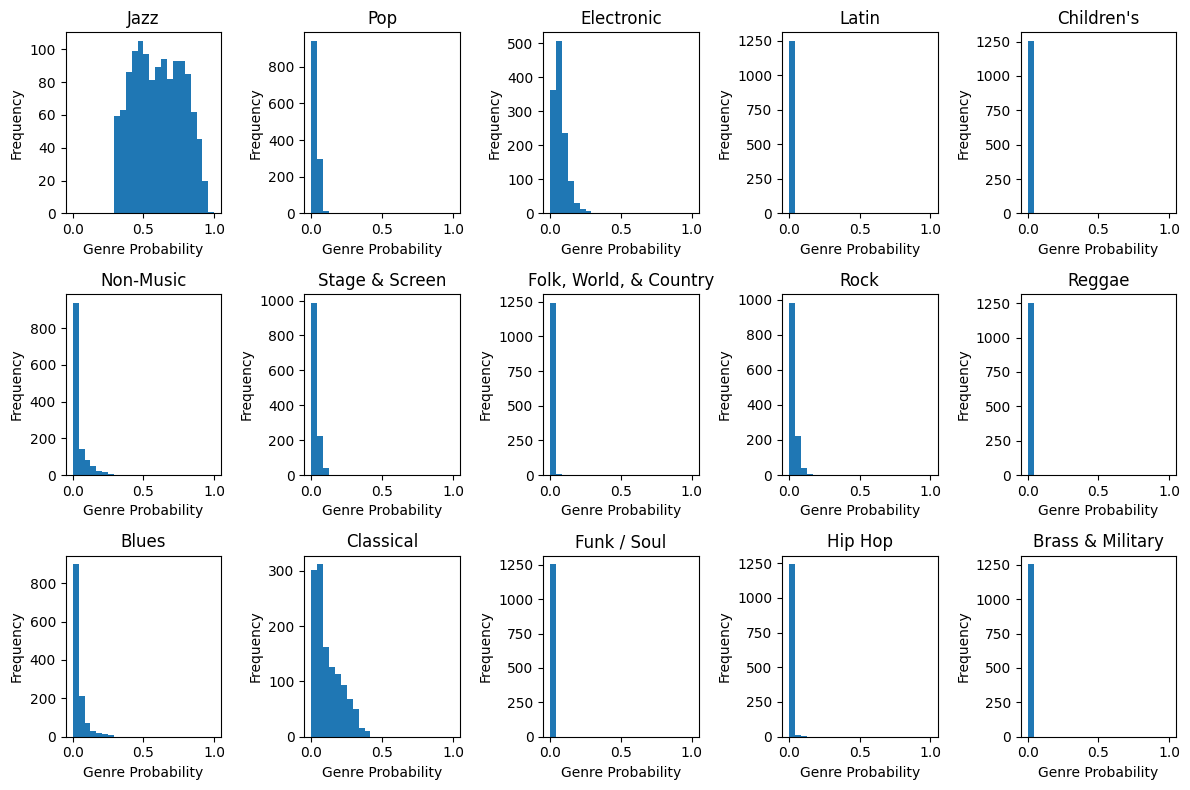

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from jazzgen.clf_utils import GENRES

fig, ax = plt.subplots(3, 5, figsize=(12, 8))

for i, genre in enumerate(GENRES):
    scores = [v[genre.lower()] for v in res_dict.values()]
    ax[i % 3, i // 3].hist(scores, bins=np.linspace(0, 1, 25))
    ax[i % 3, i // 3].set_title(genre)

    ax[i % 3, i // 3].set_ylabel("Frequency")
    ax[i % 3, i // 3].set_xlabel("Genre Probability")

plt.tight_layout()
plt.show()

Compute mean jazz and classical scores on the whole dataset.

In [7]:
jazz_scores = []
classical_scores = []

for v in res_dict.values():
    jazz_scores.append(v["jazz"])
    classical_scores.append(v["classical"])

print(f"Mean jazz score: {np.mean(jazz_scores):.3f} +- {np.std(jazz_scores) / np.sqrt(len(jazz_scores)):.3f}")
print(f"Mean classical score: {np.mean(classical_scores):.3f} +- {np.std(classical_scores) / np.sqrt(len(classical_scores)):.3f}")

Mean jazz score: 0.445 +- 0.006
Mean classical score: 0.199 +- 0.004


Filter so we keep only samples where jazz is most prominent and the model is at least 30% certain.

In [17]:
filtered_dict = {k: v for k, v in res_dict.items() if v["jazz"] == max(v.values()) and v["jazz"] > 0.3}
print(len(filtered_dict))

1254


Recompute mean scores.

In [18]:
jazz_scores = []
classical_scores = []

for v in filtered_dict.values():
    jazz_scores.append(v["jazz"])
    classical_scores.append(v["classical"])

print(f"Mean jazz score: {np.mean(jazz_scores):.3f} +- {np.std(jazz_scores) / np.sqrt(len(jazz_scores)):.3f}")
print(f"Mean classical score: {np.mean(classical_scores):.3f} +- {np.std(classical_scores) / np.sqrt(len(classical_scores)):.3f}")

Mean jazz score: 0.604 +- 0.005
Mean classical score: 0.118 +- 0.003
